<bound method NDFrame.head of           cement       water    aggregate  age   strength
0     249.816048  203.816357  1069.081198   28   9.006162
1     480.285723  195.836376  1118.672559   25  42.834509
2     392.797577  105.128413   900.187160   58  33.938228
3     339.463394  168.249566  1049.949640  297  32.749873
4     162.407456  176.039124  1028.698393  134  10.680745
...          ...         ...          ...  ...        ...
1495  367.285119  273.059152  1044.043169  163  23.323915
1496  347.796138  131.454642   995.271070   98  29.551619
1497  285.397618  161.957572   853.272850  156  28.116762
1498  251.914312  158.009106   904.533207    2  15.967840
1499  445.333460  274.282807   967.639789  350  41.821308

[1500 rows x 5 columns]>
(1500, 5)


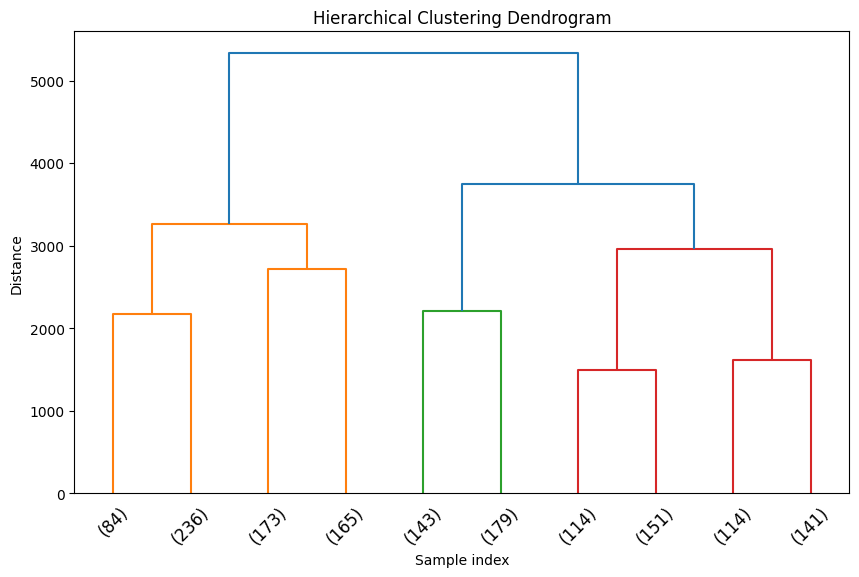

--- Mean Feature Values per Cluster ---
         cement   water  aggregate     age  strength
Cluster                                             
1        399.48  195.01     988.72  271.65     33.53
2        417.75  202.91     985.92   92.71     32.35
3        206.56  188.35     890.75  147.76     12.72
4        205.93  203.85    1039.74  275.11     13.40
5        233.34  213.61    1104.45  105.86     13.84


In [9]:
# 9. CIVIL / CONSTRUCTION
# Material composition plays a critical role in determining the strength and durability of construction materials. 
# The relationship between input components and output strength is often nonlinear and influenced by multiple factors. 
# Using material composition data, analyze patterns to identify combinations that lead to different strength characteristics and support decision-making
# in construction design.

# Hierarchical Clustering
# Cluster material compositions based on input features to identify groups with similar strength characteristics.

import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt


df = pd.read_csv('CIVIL.csv')
print(df.head)
print(df.shape)


# Perform hierarchical clustering
linked = linkage(df, method='ward')  # Try 'single', 'complete', 'average'
# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, truncate_mode='lastp', p=10, leaf_rotation=45.)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

#From dendogram , there are 5 clusters
df['Cluster'] = fcluster(linked, t=5, criterion='maxclust')

# Calculate cluster profiles (Means)
cluster_profiles = df.groupby('Cluster').mean()
print("--- Mean Feature Values per Cluster ---")
print(cluster_profiles.round(2))


       cement       water    aggregate  age
0  249.816048  203.816357  1069.081198   28
1  480.285723  195.836376  1118.672559   25
2  392.797577  105.128413   900.187160   58
3  339.463394  168.249566  1049.949640  297
4  162.407456  176.039124  1028.698393  134
  strength_category
0               low
1              high
2              high
3              high
4               low


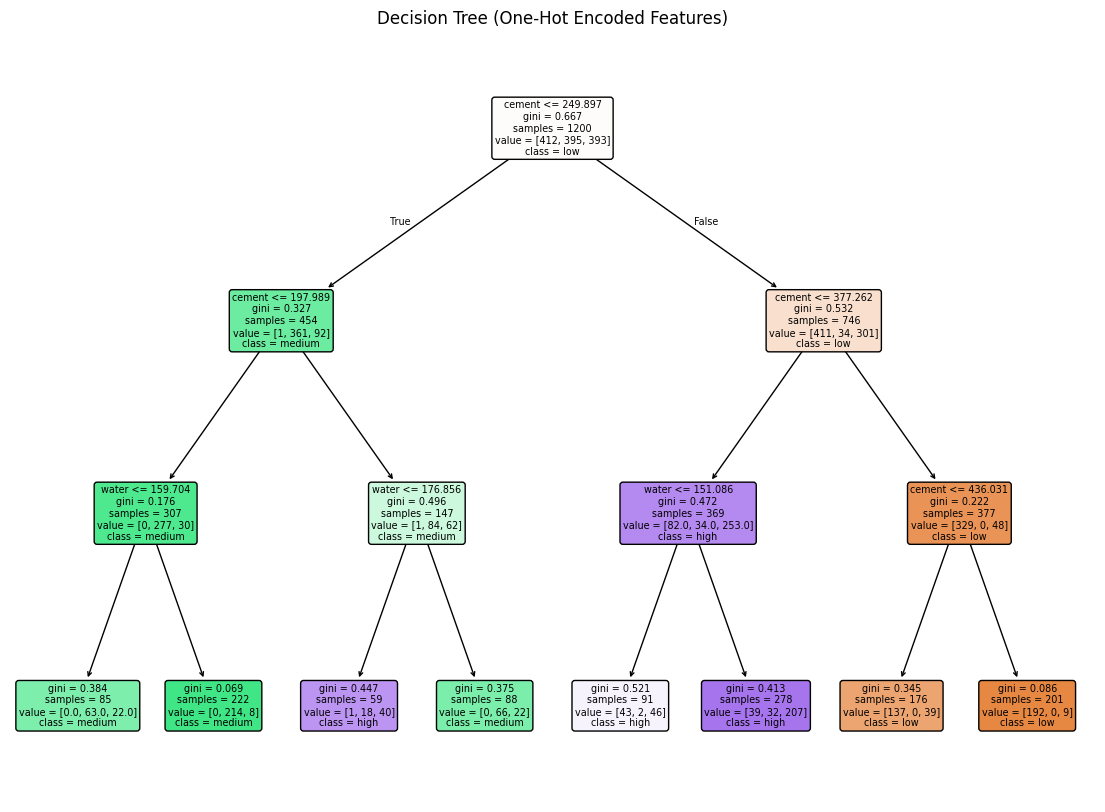

Accuracy: 0.80
--- GENERATED CLASSIFICATION RULES ---
|--- cement <= 249.90
|   |--- cement <= 197.99
|   |   |--- water <= 159.70
|   |   |   |--- class: low
|   |   |--- water >  159.70
|   |   |   |--- class: low
|   |--- cement >  197.99
|   |   |--- water <= 176.86
|   |   |   |--- class: medium
|   |   |--- water >  176.86
|   |   |   |--- class: low
|--- cement >  249.90
|   |--- cement <= 377.26
|   |   |--- water <= 151.09
|   |   |   |--- class: medium
|   |   |--- water >  151.09
|   |   |   |--- class: medium
|   |--- cement >  377.26
|   |   |--- cement <= 436.03
|   |   |   |--- class: high
|   |   |--- cement >  436.03
|   |   |   |--- class: high



In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = df.dropna(axis=1, how='all')
# Decision Tree
# Develop rules to classify material strength categories based on composition and curing time.
X = df.drop(columns=['strength', 'strength_category', 'Cluster'], axis=1)
# Convert continuous strength into 3 equal-sized categories
df['strength_category'] = pd.qcut(df['strength'], q=3, labels=['low', 'medium', 'high'])

# Set your new categorical column as the target
y = df[['strength_category']]

print(X.head())
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

plt.figure(figsize=(14, 10))
plot_tree(clf,
          feature_names=X.columns,
          class_names=['low', 'medium', 'high'],
          filled=True,
          rounded=True)
plt.title("Decision Tree (One-Hot Encoded Features)")
plt.show()

y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

feature_names = list(X.columns)
class_names = [str(cls) for cls in clf.classes_]
tree_rules = export_text(clf, feature_names=feature_names, class_names=class_names)

print("--- GENERATED CLASSIFICATION RULES ---")
print(tree_rules)


In [36]:
# Naive Bayes
# Predict material quality category using composition features.

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

X = df[['cement', 'water', 'aggregate', 'age']]
y = df['strength_category']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
y_pred = nb_classifier.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print(classification_report(y_test, y_pred))


#As the data is non-linear here - using DT is better

Model Accuracy: 0.78

              precision    recall  f1-score   support

        high       0.81      0.88      0.84       137
         low       0.82      0.88      0.85       161
      medium       0.71      0.61      0.65       152

    accuracy                           0.78       450
   macro avg       0.78      0.79      0.78       450
weighted avg       0.78      0.78      0.78       450

